# Path Sampling

Path sampling runs many A* searches with varied dropout to generate diverse paths between two crystal structures, then evaluates their energies using a machine learning potential. The path with the lowest barrier represents the best estimate of the minimum energy pathway found so far.

This guide explains how path sampling works and how to use it.

## The Role of Dropout in Path Diversity

A* search is deterministic: given the same inputs, it always produces the same path. This is problematic when we want to explore different regions of the energy landscape. The path A* finds might have a high barrier, while a slightly different path could have a much lower one.

Dropout introduces controlled randomness. At each step of A*, some fraction of valid neighbors are randomly excluded from consideration. Different dropout values (and different random number sequences) lead A* to explore different parts of the search space and find different paths.

By running many searches with varied dropout, we sample the space of possible paths. The more samples we take, the more likely we are to find a good (low barrier) path.

## Energy Evaluation with GRACE

Each path found by A* is just a sequence of CNF coordinates. To measure its barrier, we need to evaluate the energy of each structure along the path. The barrier is simply the maximum energy encountered.

We use GRACE, a machine learning interatomic potential, to evaluate energies. GRACE provides fast, reasonably accurate energies without running expensive DFT calculations. The energies are not as accurate as DFT, but they're good enough to identify promising paths that can be refined later.

Energy evaluation is often the computational bottleneck. Each path might contain hundreds of structures, and each energy evaluation takes a few milliseconds. To avoid redundant calculations, we maintain an energy cache: if the same CNF coordinate appears in multiple paths, we reuse the cached energy rather than recomputing it.

## A Simple Example

Let's sample paths between two zirconium structures. We'll first convert the structures to CNF, then run path sampling.

In [1]:
from pymatgen.core import Structure, Lattice
from cnf import CNFConstructor

# HCP zirconium (2 atoms per cell)
a_hcp, c_hcp = 3.23, 5.15
lattice_hcp = Lattice.hexagonal(a_hcp, c_hcp)
zr_hcp = Structure(
    lattice_hcp,
    ["Zr", "Zr"],
    [[0, 0, 0], [1/3, 2/3, 0.5]]
)

# BCC-like zirconium (2 atoms, different structure)
# Use a tetragonal cell with different c/a ratio
a_bcc = 3.6
lattice_bcc = Lattice.tetragonal(a_bcc, a_bcc * 1.1)
zr_bcc = Structure(
    lattice_bcc,
    ["Zr", "Zr"],
    [[0, 0, 0], [0.5, 0.5, 0.5]]
)

print(f"HCP volume: {zr_hcp.volume:.2f} Ang^3")
print(f"BCC-like volume: {zr_bcc.volume:.2f} Ang^3")

# Convert to CNF at moderate resolution
xi = 1.5
delta = 30
constructor = CNFConstructor(xi=xi, delta=delta)

start_cnf = constructor.from_pymatgen_structure(zr_hcp).cnf
goal_cnf = constructor.from_pymatgen_structure(zr_bcc).cnf

print(f"\nStart CNF (HCP): {start_cnf.coords[:7]}...")
print(f"Goal CNF (BCC):  {goal_cnf.coords[:7]}...")

HCP volume: 46.53 Ang^3
BCC-like volume: 51.32 Ang^3

Start CNF (HCP): (7, 7, 18, 25, 7, 25, 25)...
Goal CNF (BCC):  (8, 9, 10, 26, 17, 17, 19)...


In [2]:
from cnf.navigation.astar.iterative import sample
from cnf.calculation.grace import GraceCalcProvider

# Use GRACE foundation model for energy evaluation
calc_provider = GraceCalcProvider()

result = sample(
    start_cnfs=[start_cnf],
    goal_cnfs=[goal_cnf],
    calc_provider=calc_provider,
    num_samples=3,
    dropout_range=(0.05, 0.15),
    min_distance=1.5,
    max_iterations=2000,
    verbosity=1,
)

[tensorpotential] Info: Environment variable TF_USE_LEGACY_KERAS is automatically set to '1'.


Using cached GRACE model from /Users/maxg/.cache/grace/GRACE-FS-OAM
Model license: Academic Software License


2026-03-13 19:19:55.524190: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x121ec7010 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-03-13 19:19:55.524203: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Host, Default Version
2026-03-13 19:19:55.660942: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.



Path sampling: 3 attempts (dropout 0.05-0.15, serial)
  max_iters: 2000
  Min distance filter: 1.50 Å
  [1/3] dropout=0.07 forward... 

len=29, barrier=-15.7547 eV, iters=29
  [2/3] dropout=0.12 forward... 

len=29, barrier=-15.7547 eV, iters=29
  [3/3] dropout=0.06 forward... 

2026-03-13 19:19:56.530417: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-03-13 19:19:56.534750: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.


len=29, barrier=-15.6420 eV, iters=29

Sampling complete:
  Paths found: 3/3
  Best barrier: -15.7547 eV
  Best path length: 29 steps
  Energy cache size: 40
  Total time: 0.2s


The output shows each attempt with its dropout value, whether a path was found, and if so, the path length and barrier height. At the end, we see summary statistics including the best barrier found.

In [3]:
print(f"Paths found: {len(result.paths)}/{len(result.attempts)}")
print(f"Best barrier: {result.best_barrier:.4f} eV")
print(f"Best path length: {len(result.best_path)} steps")

Paths found: 3/3
Best barrier: -15.7547 eV
Best path length: 29 steps


## Understanding the Result

The `SearchResult` contains all attempts, both successful and unsuccessful. Each attempt records whether a path was found, how many A* iterations it took, and the dropout value used.

In [4]:
# Look at individual attempts
for i, attempt in enumerate(result.attempts[:5]):
    if attempt.found:
        print(f"Attempt {i+1}: dropout={attempt.metadata['dropout']:.2f}, "
              f"barrier={attempt.path.barrier:.4f} eV, "
              f"length={len(attempt.path)}")
    else:
        print(f"Attempt {i+1}: dropout={attempt.metadata['dropout']:.2f}, no path found")

Attempt 1: dropout=0.07, barrier=-15.7547 eV, length=29
Attempt 2: dropout=0.12, barrier=-15.7547 eV, length=29
Attempt 3: dropout=0.06, barrier=-15.6420 eV, length=29


## Examining the Best Path

The best path is the one with the lowest barrier. We can examine its energy profile to understand the transformation.

Path length: 29 steps
Barrier: -15.7547 eV


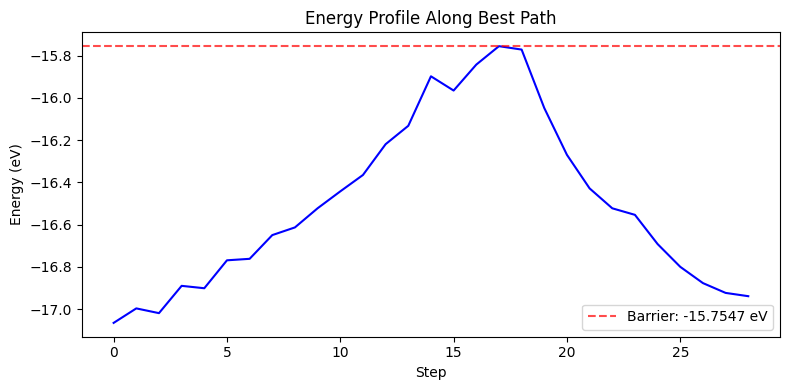

In [5]:
import matplotlib.pyplot as plt

best_path = result.best_path

print(f"Path length: {len(best_path)} steps")
print(f"Barrier: {best_path.barrier:.4f} eV")

# Plot the energy profile
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(best_path.energies, 'b-', linewidth=1.5)
ax.axhline(best_path.barrier, color='r', linestyle='--', alpha=0.7, label=f'Barrier: {best_path.barrier:.4f} eV')
ax.set_xlabel('Step')
ax.set_ylabel('Energy (eV)')
ax.set_title('Energy Profile Along Best Path')
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# What types of steps does the path contain?
step_types = best_path.get_step_types()
if step_types:
    lattice_steps = step_types.count('lattice')
    motif_steps = step_types.count('motif')
    print(f"Lattice steps: {lattice_steps}")
    print(f"Motif steps: {motif_steps}")

Lattice steps: 18
Motif steps: 10


## Dropout Range

The `dropout_range` parameter controls the range of dropout values used across attempts. Each attempt samples uniformly from this range.

Low dropout (0.02-0.05) produces paths similar to the deterministic A* result, with small variations. High dropout (0.2-0.3) produces very different paths but may fail to find any path at all because too many neighbors are excluded.

A moderate range like (0.05, 0.1) balances path diversity with success rate. If you find that many attempts fail, try lowering the upper bound. If all paths look similar, try raising the lower bound.

Using cached GRACE model from /Users/maxg/.cache/grace/GRACE-FS-OAM
Model license: Academic Software License



Path sampling: 3 attempts (dropout 0.10-0.20, serial)
  max_iters: 2000
  Min distance filter: 1.50 Å
  [1/3] dropout=0.19 forward... 

len=27, barrier=-16.1541 eV, iters=27
  [2/3] dropout=0.18 forward... 

len=31, barrier=-15.7547 eV, iters=31
  [3/3] dropout=0.16 forward... 

len=29, barrier=-15.6420 eV, iters=31

Sampling complete:
  Paths found: 3/3
  Best barrier: -16.1541 eV
  Best path length: 27 steps
  Energy cache size: 62
  Total time: 0.3s


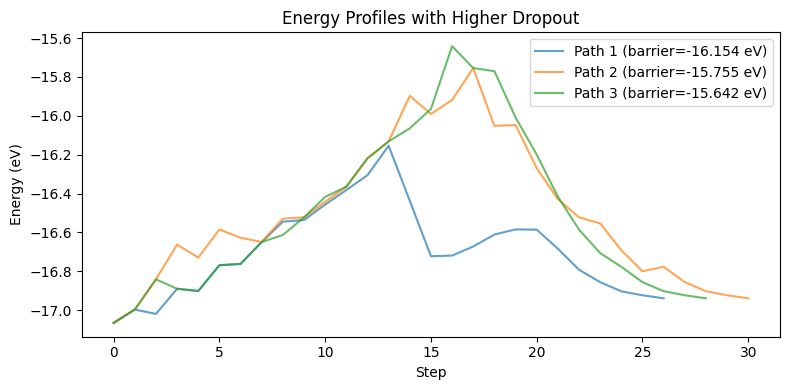

In [7]:
# Try with higher dropout for more diversity
result_high_dropout = sample(
    start_cnfs=[start_cnf],
    goal_cnfs=[goal_cnf],
    calc_provider=calc_provider,
    num_samples=3,
    dropout_range=(0.1, 0.2),
    min_distance=1.5,
    max_iterations=2000,
    verbosity=1,
)

# Compare energy profiles from different dropout settings
fig, ax = plt.subplots(figsize=(8, 4))
for i, path in enumerate(result_high_dropout.paths):
    ax.plot(path.energies, alpha=0.7, label=f'Path {i+1} (barrier={path.barrier:.3f} eV)')
ax.set_xlabel('Step')
ax.set_ylabel('Energy (eV)')
ax.set_title('Energy Profiles with Higher Dropout')
ax.legend()
plt.tight_layout()
plt.show()

## Bidirectional Sampling

By default, all sampling attempts search from start to goal. The `bidirectional` option causes about half the attempts to search in the reverse direction (goal to start). This can help discover paths that are easier to find in one direction than the other.

Note that when a reverse path is found, it's automatically reversed before energy evaluation, so all paths in the result go from start to goal regardless of which direction was searched.

In [8]:
# Bidirectional sampling
result_bidir = sample(
    start_cnfs=[start_cnf],
    goal_cnfs=[goal_cnf],
    calc_provider=calc_provider,
    num_samples=4,
    dropout_range=(0.05, 0.1),
    bidirectional=True,
    min_distance=1.5,
    max_iterations=2000,
    verbosity=1,
)

# Check the directions used
forward = sum(1 for a in result_bidir.attempts if a.metadata.get('direction') == 'forward')
backward = sum(1 for a in result_bidir.attempts if a.metadata.get('direction') == 'backward')
print(f"\nForward attempts: {forward}, Backward attempts: {backward}")

Using cached GRACE model from /Users/maxg/.cache/grace/GRACE-FS-OAM
Model license: Academic Software License



Path sampling: 4 attempts (dropout 0.05-0.10, serial)
  max_iters: 2000
  Min distance filter: 1.50 Å
  [1/4] dropout=0.08 backward... 

len=30, barrier=-16.9225 eV, iters=30
  [2/4] dropout=0.05 forward... 

len=29, barrier=-15.7547 eV, iters=29


  [3/4] dropout=0.08 backward... 

len=29, barrier=-16.9054 eV, iters=30
  [4/4] dropout=0.08 backward... 

len=29, barrier=-16.8728 eV, iters=29

Sampling complete:
  Paths found: 4/4
  Best barrier: -16.9225 eV
  Best path length: 30 steps
  Energy cache size: 82
  Total time: 0.3s

Forward attempts: 1, Backward attempts: 3


## Parallel Sampling

Sampling attempts are independent and can be run in parallel. The `n_workers` parameter controls parallelization. Each worker creates its own energy calculator, so GPU memory and CPU resources are distributed across workers.

The implementation uses Python's ProcessPoolExecutor with the 'spawn' context to avoid issues with TensorFlow and fork. Each worker receives a `CalcProvider` (a picklable factory) and creates its own calculator instance, with TensorFlow threading adjusted to avoid contention.

In [9]:
# Parallel sampling with 2 workers
result_parallel = sample(
    start_cnfs=[start_cnf],
    goal_cnfs=[goal_cnf],
    calc_provider=calc_provider,
    num_samples=4,
    dropout_range=(0.05, 0.1),
    min_distance=1.5,
    max_iterations=2000,
    n_workers=2,
    verbosity=1,
)


Path sampling: 4 attempts (dropout 0.05-0.10, parallel (2 workers))
  max_iters: 2000
  Min distance filter: 1.50 Å


2026-03-13 19:20:05.671858: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x331ba7660 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-03-13 19:20:05.671873: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Host, Default Version
2026-03-13 19:20:05.719485: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x1257130e0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-03-13 19:20:05.719503: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Host, Default Version
2026-03-13 19:20:05.785551: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-13 19:20:05.833787: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to 

2026-03-13 19:20:06.649123: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-03-13 19:20:06.656474: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2026-03-13 19:20:06.698654: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-03-13 19:20:06.705275: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.


  [1/4] attempt 1: barrier=-15.6420 eV
  [2/4] attempt 2: barrier=-15.6420 eV
  [3/4] attempt 3: barrier=-15.7547 eV
  [4/4] attempt 4: barrier=-15.6420 eV
Using cached GRACE model from /Users/maxg/.cache/grace/GRACE-FS-OAM
Model license: Academic Software License
  [Sample Worker PID 7194] Ready in 0.4s - GraceMLIPCalculator(model=GRACE-FS-OAM)
Using cached GRACE model from /Users/maxg/.cache/grace/GRACE-FS-OAM
Model license: Academic Software License
  [Sample Worker PID 7193] Ready in 0.4s - GraceMLIPCalculator(model=GRACE-FS-OAM)



Sampling complete:
  Paths found: 4/4
  Best barrier: -15.7547 eV
  Best path length: 29 steps
  Energy cache size: 47
  Total time: 7.0s


## Custom Calculator

By default, sampling uses a GRACE foundation model. If you have a fine-tuned model for your material system, you can provide a custom calculator via `CalcProvider`.

The `CalcProvider` is a picklable factory that creates calculator instances. This pattern is necessary because calculator objects (which contain loaded ML models) cannot be directly pickled and sent to worker processes. Instead, each worker receives the provider and creates its own calculator.

In [10]:
from cnf.calculation.grace import GraceCalcProvider

# Using a custom fine-tuned model (commented out since path is hypothetical)
# custom_provider = GraceCalcProvider(model_path="/path/to/fine_tuned_model")
# result_custom = sample(
#     start_cnfs=[start_cnf],
#     goal_cnfs=[goal_cnf],
#     calc_provider=custom_provider,
#     num_samples=3,
#     max_iterations=2000,
# )

# For quick testing without ML model overhead, use ConstantCalcProvider
from cnf.calculation.constant_calculator import ConstantCalcProvider

test_provider = ConstantCalcProvider(val=0.0)
result_test = sample(
    start_cnfs=[start_cnf],
    goal_cnfs=[goal_cnf],
    calc_provider=test_provider,
    num_samples=3,
    dropout_range=(0.05, 0.1),
    min_distance=1.5,
    max_iterations=2000,
    verbosity=1,
)

print(f"\nWith constant energy, all barriers are: {result_test.best_barrier}")


Path sampling: 3 attempts (dropout 0.05-0.10, serial)
  max_iters: 2000
  Min distance filter: 1.50 Å
  [1/3] dropout=0.09 forward... 

len=29, barrier=0.0000 eV, iters=29
  [2/3] dropout=0.09 forward... 

len=31, barrier=0.0000 eV, iters=31
  [3/3] dropout=0.08 forward... 

len=29, barrier=0.0000 eV, iters=29

Sampling complete:
  Paths found: 3/3
  Best barrier: 0.0000 eV
  Best path length: 29 steps
  Energy cache size: 39
  Total time: 0.1s

With constant energy, all barriers are: 0.0


## Saving and Loading Results

Sampling results can be saved to JSON. The `output_dir` parameter causes automatic saving, with intermediate saves every 10 attempts (useful for long runs that might be interrupted).

In [11]:
import tempfile
import os

with tempfile.TemporaryDirectory() as tmpdir:
    result_saved = sample(
        start_cnfs=[start_cnf],
        goal_cnfs=[goal_cnf],
        calc_provider=calc_provider,
        num_samples=3,
        dropout_range=(0.05, 0.1),
        min_distance=1.5,
        max_iterations=2000,
        output_dir=tmpdir,
        verbosity=0,
    )
    
    saved_path = os.path.join(tmpdir, "sample_result.json")
    print(f"Saved to: {saved_path}")
    print(f"File exists: {os.path.exists(saved_path)}")

Using cached GRACE model from /Users/maxg/.cache/grace/GRACE-FS-OAM
Model license: Academic Software License


  [Sample] Saved: /var/folders/20/rp8b8xzd0tn81qzlh8zmmvg00000gn/T/tmp3an73ipc/sample_result.json
Saved to: /var/folders/20/rp8b8xzd0tn81qzlh8zmmvg00000gn/T/tmp3an73ipc/sample_result.json
File exists: True


In [12]:
# Loading a saved result
from cnf.navigation.astar.models import SearchResult

with tempfile.TemporaryDirectory() as tmpdir:
    outpath = os.path.join(tmpdir, "sample_result.json")
    result.to_json(outpath)
    
    loaded = SearchResult.from_json(outpath)
    print(f"Loaded {len(loaded.paths)} paths")
    print(f"Best barrier: {loaded.best_barrier:.4f} eV")

Loaded 3 paths
Best barrier: -15.7547 eV


## Using the Results

The main output of path sampling is the best barrier found across all sampled paths. This gives an upper bound on the true minimum energy barrier between the two structures. More samples generally lead to better (lower) estimates.

The sampling result also provides useful statistics like the maximum iterations used by successful attempts, which can help calibrate iteration limits for future searches.

In [13]:
print(f"Best barrier: {result.best_barrier:.4f} eV")
print(f"Max successful iterations: {result.max_successful_iterations}")
print(f"Success rate: {result.success_rate:.1%}")

Best barrier: -15.7547 eV
Max successful iterations: 29
Success rate: 100.0%


## Summary

Path sampling generates diverse transformation pathways by running many A* searches with varied dropout. Each path is evaluated using a machine learning potential to measure its energy barrier.

The main outputs are:

1. Multiple paths with their energies and barriers
2. The best (lowest) barrier found
3. Iteration statistics that can help calibrate future searches

The best barrier found in sampling is an upper bound on the true minimum barrier. Taking more samples increases the likelihood of finding lower-barrier paths.